## Pull economic & calendar features

**Natural gas price** — Henry Hub spot price from FRED (free, no API key).  
Daily → forward-filled to hourly.

**Calendar features** — computed from the datetime index, no fetch needed:
- `is_holiday` — US federal holidays
- `is_weekend` — Saturday / Sunday
- `hour_of_day`, `day_of_week`, `month` — cyclic time context

Output: `data/raw/economic_hourly.csv`

In [5]:
import requests
import pandas as pd
import holidays
import os
import matplotlib.pyplot as plt

START = '2019-01-01'
END   = '2024-12-31'
OUTPUT = '../../data/raw/economic_hourly.csv'

### 1. Henry Hub natural gas spot price (FRED)

In [6]:
r = requests.get('https://fred.stlouisfed.org/graph/fredgraph.csv?id=DHHNGSP', timeout=30)
r.raise_for_status()

ng = pd.read_csv(
    pd.io.common.StringIO(r.text),
    parse_dates=['observation_date'],
    index_col='observation_date'
)
ng.columns = ['gas_price_mmbtu']
ng = ng.replace('.', float('nan'))  # FRED uses '.' for missing
ng['gas_price_mmbtu'] = pd.to_numeric(ng['gas_price_mmbtu'], errors='coerce')
ng = ng.loc[START:END]

print(f'{len(ng)} trading days  |  missing: {ng["gas_price_mmbtu"].isna().sum()}')
ng.tail()

1566 trading days  |  missing: 63


,gas_price_mmbtu
observation_date,
2024-12-25,NaN
2024-12-26,2.96
2024-12-27,2.91
2024-12-30,3.39
2024-12-31,3.40


### 2. Build hourly datetime index and expand gas price

In [7]:
# Full hourly index matching the CAISO data (Pacific time, no DST suffix)
hourly_idx = pd.date_range(start=START, end=END + ' 23:00', freq='h', tz='America/Los_Angeles')

df = pd.DataFrame(index=hourly_idx)
df.index.name = 'datetime'

# Reindex gas price to hourly then forward-fill (weekends + holidays have no trading price)
ng.index = pd.DatetimeIndex(ng.index).tz_localize('America/Los_Angeles')
df['gas_price_mmbtu'] = ng['gas_price_mmbtu'].reindex(df.index, method='ffill')

print(f'Hourly rows: {len(df):,}  |  gas NaN after ffill: {df["gas_price_mmbtu"].isna().sum()}')

Hourly rows: 52,608  |  gas NaN after ffill: 2136


### 3. Calendar features

In [ ]:
ca_holidays = holidays.country_holidays('US', subdiv='CA', years=range(2019, 2025))

dates = df.index.normalize()  # date portion only

df['is_holiday'] = dates.isin(ca_holidays).astype(int)
df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)
df['hour_of_day'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month

print(f'Holidays in range: {df["is_holiday"].sum():,} hours  ({df["is_holiday"].sum()/24:.0f} days)')
print(f'Weekend hours:     {df["is_weekend"].sum():,}')
df.head()

Holidays in range: 0 hours  (0 days)
Weekend hours:     15,024


/var/folders/k9/9509h1kd7_vb9zj9ql8q9xv40000gn/T/ipykernel_13562/4183284356.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns, America/Los_Angeles] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['is_holiday'] = dates.isin(ca_holidays).astype(int)


,gas_price_mmbtu,is_holiday,is_weekend,hour_of_day,day_of_week,month
datetime,,,,,,
2019-01-01 00:00:00-08:00,NaN,0,0,0,1,1
2019-01-01 01:00:00-08:00,NaN,0,0,1,1,1
2019-01-01 02:00:00-08:00,NaN,0,0,2,1,1
2019-01-01 03:00:00-08:00,NaN,0,0,3,1,1
2019-01-01 04:00:00-08:00,NaN,0,0,4,1,1


In [9]:
os.makedirs(os.path.dirname(OUTPUT), exist_ok=True)
df.to_csv(OUTPUT)
print(f'Saved {len(df):,} rows → {OUTPUT}')
print(df.describe().round(2))

Saved 52,608 rows → ../../data/raw/economic_hourly.csv
       gas_price_mmbtu  is_holiday  is_weekend  hour_of_day  day_of_week  \
count         50472.00     52608.0    52608.00     52608.00      52608.0   
mean              3.27         0.0        0.29        11.50          3.0   
std               1.87         0.0        0.45         6.92          2.0   
min               1.21         0.0        0.00         0.00          0.0   
25%               2.15         0.0        0.00         5.75          1.0   
50%               2.61         0.0        0.00        11.50          3.0   
75%               3.70         0.0        1.00        17.25          5.0   
max              23.86         0.0        1.00        23.00          6.0   

          month  
count  52608.00  
mean       6.52  
std        3.45  
min        1.00  
25%        4.00  
50%        7.00  
75%       10.00  
max       12.00  


### 4. Quick plots

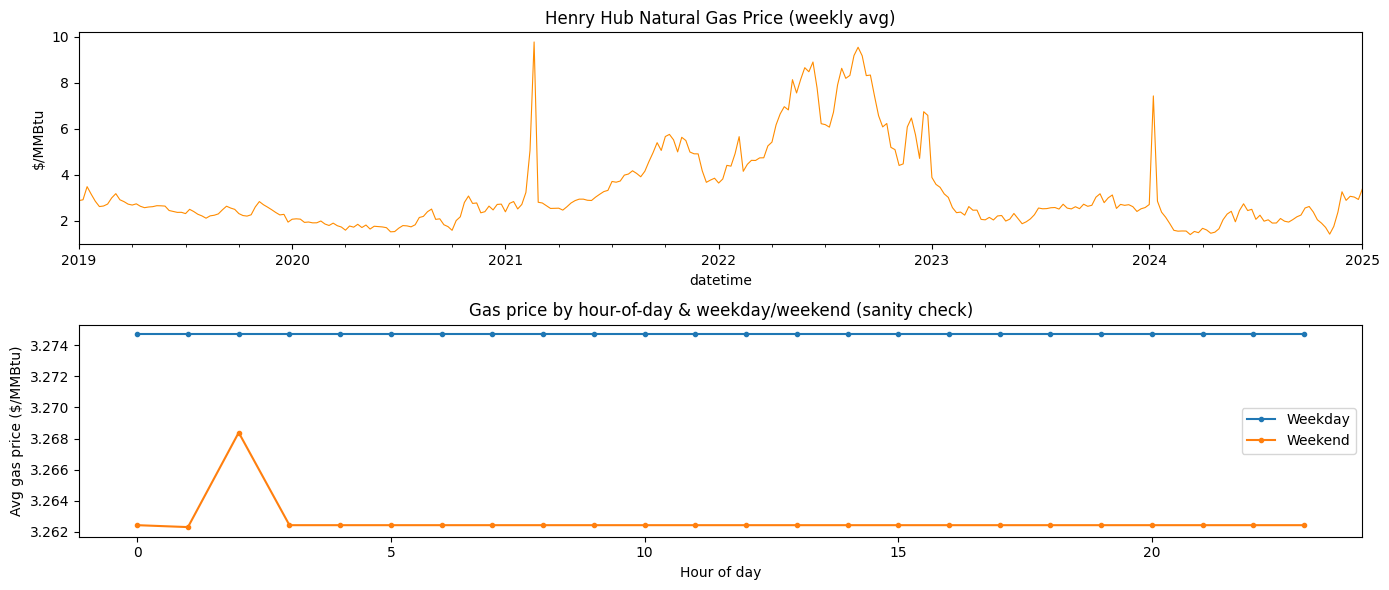

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

# Gas price over time
df['gas_price_mmbtu'].resample('W').mean().plot(ax=axes[0], linewidth=0.8, color='darkorange')
axes[0].set_ylabel('$/MMBtu')
axes[0].set_title('Henry Hub Natural Gas Price (weekly avg)')

# Average hourly load profile: weekday vs weekend vs holiday
# (placeholder — will make more sense once merged with load)
avg_by_hour = df.groupby(['hour_of_day', 'is_weekend'])['gas_price_mmbtu'].mean().unstack()
avg_by_hour.columns = ['Weekday', 'Weekend']
avg_by_hour.plot(ax=axes[1], marker='o', markersize=3)
axes[1].set_xlabel('Hour of day')
axes[1].set_ylabel('Avg gas price ($/MMBtu)')
axes[1].set_title('Gas price by hour-of-day & weekday/weekend (sanity check)')

plt.tight_layout()
plt.show()